# C172 Flight Dynamics Simulation

## Imports

In [1]:
from pathlib import Path
import sys

ROOT_DIR = Path.cwd()
if not (ROOT_DIR / "data").exists():
    ROOT_DIR = ROOT_DIR.parent
if str(ROOT_DIR) not in sys.path:
    sys.path.insert(0, str(ROOT_DIR))

DATA_DIR = ROOT_DIR / "data"

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import least_squares
import pandas as pd

from aircraft.c172_params import params, t0, tf, dt, alt_0
from models.aircraft_longitudinal_dynamics import aircraft_longitudinal_dynamics, elevator_deflection
from models.drag_polar import drag_polar, power_required, power_curves, velocity_max
from solvers.trim_solver import longitudinal_trim
from utils import conversions as conv
from utils.integrators import RK4

%matplotlib inline

## Performance Analysis

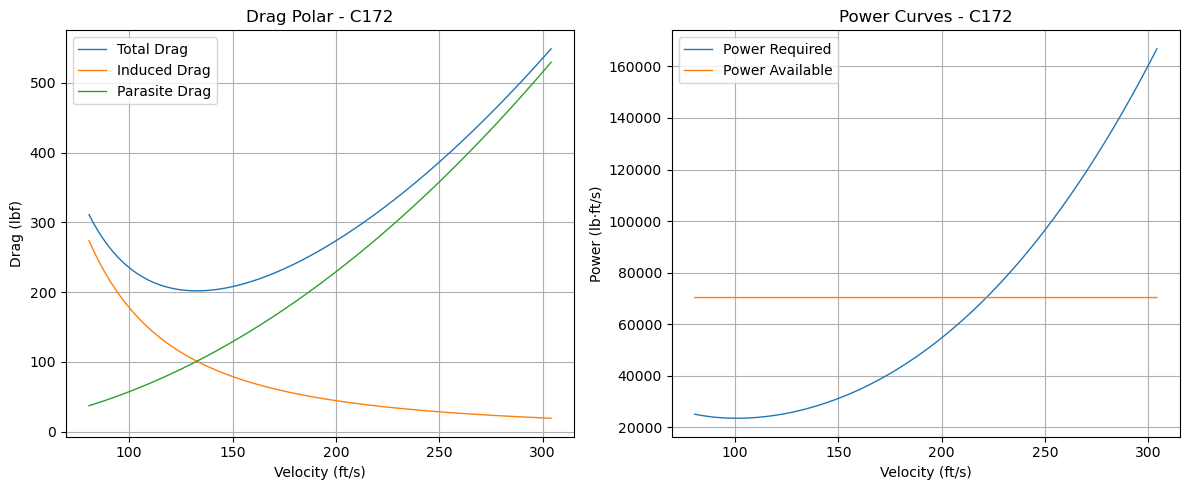

In [2]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

V, D, D_i, D_p = drag_polar(alt_0, params)
ax1.plot(V, D,   label="Total Drag",    linewidth=1)
ax1.plot(V, D_i, label="Induced Drag",  linewidth=1)
ax1.plot(V, D_p, label="Parasite Drag", linewidth=1)
ax1.set_xlabel("Velocity (ft/s)")
ax1.set_ylabel("Drag (lbf)")
ax1.set_title("Drag Polar - C172")
ax1.legend()
ax1.grid()

V, P_req, P_i, P_p, P_A = power_curves(alt_0, 1.0, params)
ax2.plot(V, P_req, label="Power Required",  linewidth=1)
ax2.plot(V, P_A,   label="Power Available", linewidth=1)
ax2.set_xlabel("Velocity (ft/s)")
ax2.set_ylabel("Power (lb·ft/s)")
ax2.set_title("Power Curves - C172")
ax2.legend()
ax2.grid()

plt.tight_layout()
plt.show()

In [3]:
V_max = velocity_max(alt_0, 0.75, params, 300)
print(f"Max Velocity: {V_max:.2f} ft/s | {conv.fps2kts(V_max):.2f} kts")

Max Velocity: 196.92 ft/s | 116.67 kts


## Trim

In [4]:
V_trim     = conv.kts2fps(90)
gamma_trim = np.deg2rad(0.0)
alt_trim   = 4000
trim_target = np.array([V_trim, gamma_trim, alt_trim])

x0 = np.array([0.45, np.deg2rad(-2.0), 0.0])  # throttle, delta_e, theta
x_trim, u_trim = longitudinal_trim(x0, trim_target)


Trim Target:
Velocity: 151.90290000000002 [ft/s]
Flight Path angle: 0.0 [rad]
Altitude: 4000.0 [ft]

Trim Solutions:
Throttle: 0.4511865094132903 [%]
Elevator Deflection -0.003441817655490966 [rad]
Body Angle: 0.044275872583178014 [rad]
Forward Body Velocity (U): 151.75403267702268 [ft/s]
Vertical Body Velocity (W): 6.723436224962332 [ft/s]
Pitch Rate (Q): 0.0 [rad/s]


## Dynamics

In [5]:
t, x = RK4(aircraft_longitudinal_dynamics, (0.0, tf), x_trim, dt, args=(u_trim, params,))
alpha = np.arctan2(x[:, 1], x[:, 0])

_, delta_e = u_trim
elev_hist = np.array([elevator_deflection(ti, delta_e) for ti in t])

## POH Rate of Climb

,press_alt_ft,IAS,fpm_M20C,fpm_0C,fpm_20C,fpm_40C
0,0,74,855,785,710,645.0
1,2000,73,760,695,625,560.0
2,4000,73,685,620,555,495.0
3,6000,73,575,515,450,390.0
4,8000,72,465,405,345,285.0
5,10000,72,360,300,240,180.0
6,12000,72,255,195,135,NaN


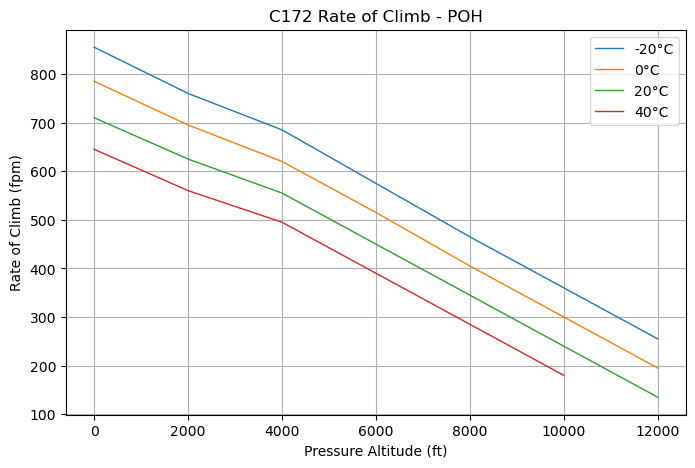

In [6]:
roc = pd.read_csv(DATA_DIR / "c172_roc.csv", sep=",", engine="python", skipinitialspace=True)
display(roc)

fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(roc["press_alt_ft"], roc["fpm_M20C"], label="-20°C", linewidth=1)
ax.plot(roc["press_alt_ft"], roc["fpm_0C"],   label="0°C",   linewidth=1)
ax.plot(roc["press_alt_ft"], roc["fpm_20C"],  label="20°C",  linewidth=1)
ax.plot(roc["press_alt_ft"], roc["fpm_40C"],  label="40°C",  linewidth=1)
ax.set_xlabel("Pressure Altitude (ft)")
ax.set_ylabel("Rate of Climb (fpm)")
ax.set_title("C172 Rate of Climb - POH")
ax.legend()
ax.grid(True)
plt.show()

## X-Plane Data

In [7]:
df = pd.read_csv(DATA_DIR / "Data.txt", sep="|", engine="python", skipinitialspace=True)
df = df.iloc[6000:9000]

alpha_deg = df["alpha,__deg "]
V_ktas    = df["Vtrue,_ktas "]

xp = {
    "time":    df["_totl,_time "] - df["_totl,_time "].iloc[0],
    "pitch":   df["pitch,__deg "],
    "delta_e": df["elev1,__deg .1"],
    "alpha":   alpha_deg,
    "alt":     df["p-alt,ftMSL "],
    "U":       V_ktas * np.cos(np.deg2rad(alpha_deg)) * 1.68781,
    "W":       V_ktas * np.sin(np.deg2rad(alpha_deg)) * 1.68781,
    "Q":       df["____Q,deg/s "],
}

## Comparison: Sim vs X-Plane

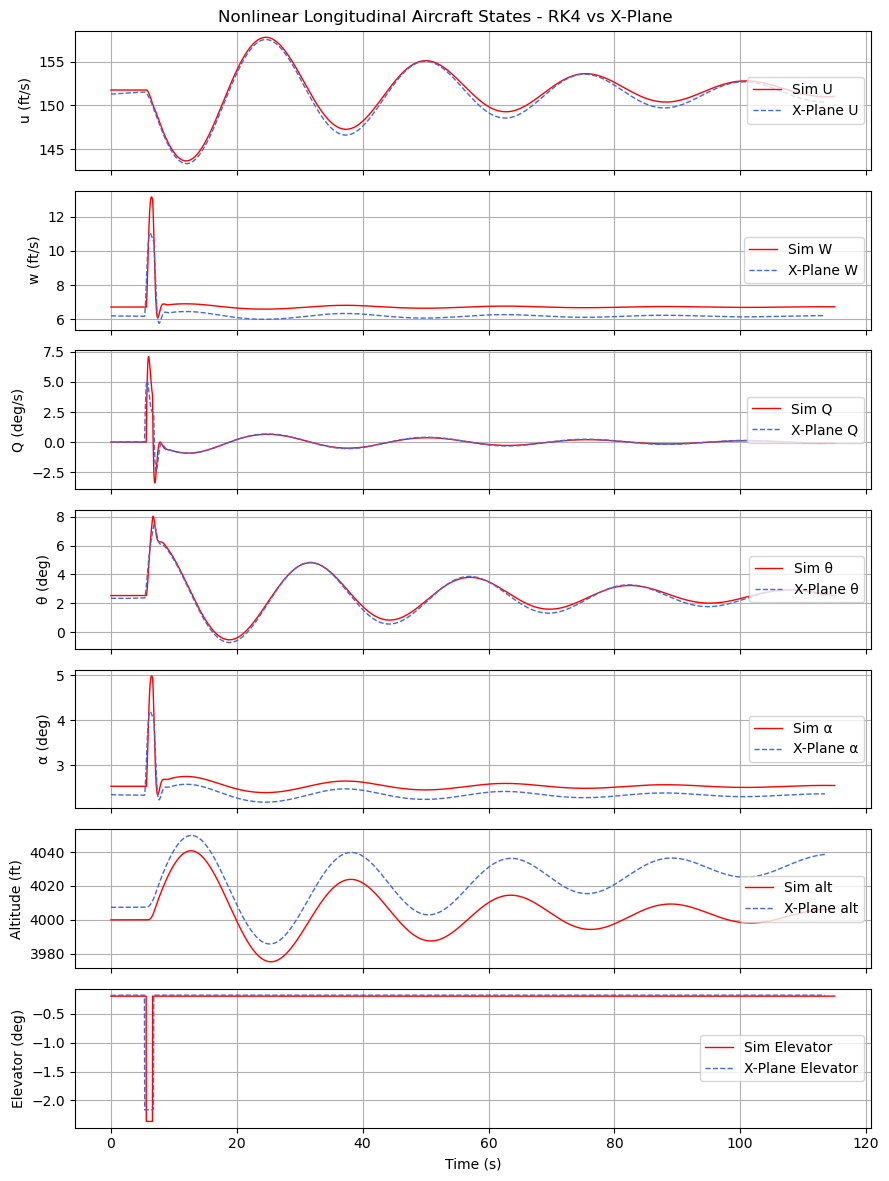

In [8]:
fig, axs = plt.subplots(7, 1, figsize=(9, 12), sharex=True)
fig.suptitle("Nonlinear Longitudinal Aircraft States - RK4 vs X-Plane")

def _plot(ax, sim_t, sim, ref_t, ref, ylabel, sim_label, ref_label):
    ax.plot(sim_t, sim, color="red",       linewidth=1)
    ax.plot(ref_t, ref, color="royalblue", linewidth=1, linestyle="dashed")
    ax.set_ylabel(ylabel)
    ax.legend([sim_label, ref_label], loc="center right")
    ax.grid(True)

_plot(axs[0], t, x[:, 0],               xp["time"], xp["U"],       "u (ft/s)",       "Sim U",          "X-Plane U")
_plot(axs[1], t, x[:, 1],               xp["time"], xp["W"],       "w (ft/s)",       "Sim W",          "X-Plane W")
_plot(axs[2], t, np.rad2deg(x[:, 2]),   xp["time"], xp["Q"],       "Q (deg/s)",      "Sim Q",          "X-Plane Q")
_plot(axs[3], t, np.rad2deg(x[:, 3]),   xp["time"], xp["pitch"],   "θ (deg)",        "Sim θ",          "X-Plane θ")
_plot(axs[4], t, np.rad2deg(alpha),     xp["time"], xp["alpha"],   "α (deg)",        "Sim α",          "X-Plane α")
_plot(axs[5], t, x[:, 4],               xp["time"], xp["alt"],     "Altitude (ft)",  "Sim alt",        "X-Plane alt")
_plot(axs[6], t, np.rad2deg(elev_hist), xp["time"], xp["delta_e"], "Elevator (deg)", "Sim Elevator",   "X-Plane Elevator")

axs[-1].set_xlabel("Time (s)")
plt.tight_layout()
plt.show()